# **Full-Cycle Kaggle Dataset Analytics**

**Install Kaggle API**

In [1]:
!pip install kaggle

**Configure Kaggle**

In [2]:
import os

os.makedirs(
    "/root/.kaggle",
    exist_ok=True
)

In [3]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username":"internship",\r\n  "key":"KGAT_5de7d76520e03721f5d7e8ff76b4f1d4"\r\n}'}

In [4]:
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

**Download Dataset**

In [7]:
!ls /root/.kaggle

kaggle.json


In [8]:
!chmod 600 /root/.kaggle/kaggle.json

In [9]:
!cat /root/.kaggle/kaggle.json

{
  "username":"internship",
  "key":"KGAT_5de7d76520e03721f5d7e8ff76b4f1d4"
}

In [10]:
!kaggle datasets list -s netflix

ref                                                            title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
netflix-inc/netflix-prize-data                                 Netflix Prize data                                   716193814  2019-11-13 18:39:37.417000         107668       1507  0.7647059        
imtkaggleteam/netflix                                          NetFlix                                                1224946  2023-11-05 08:01:21.163000           8303        126  1                
shivamb/netflix-shows                                          Netflix Movies and TV Shows                            1400865  2021-09-27 04:44:36.770000         767593       9931  1                
rohit

In [11]:
!kaggle datasets download -d shivamb/netflix-shows

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
100% 1.34M/1.34M [00:00<00:00, 119MB/s]



In [12]:
!unzip netflix-shows.zip

Archive:  netflix-shows.zip
  inflating: netflix_titles.csv      


In [13]:
!ls

netflix-shows.zip  netflix_titles.csv  sample_data


In [14]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Exploratory Profile**

In [15]:
print("Shape:", df.shape)

Shape: (8807, 12)


In [16]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [17]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [18]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [19]:
df.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


In [20]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


**Save Raw Dataset**

In [21]:
import os

os.makedirs("data", exist_ok=True)

In [22]:
df.to_csv(
    "data/raw_dataset.csv",
    index=False
)

**Data Cleaning**

In [23]:
df["director"] = df["director"].fillna(
    "Unknown"
)

In [24]:
df["cast"] = df["cast"].fillna(
    "Not Available"
)

In [25]:
df["country"] = df["country"].fillna(
    "Unknown"
)

In [26]:
df["rating"] = df["rating"].fillna(
    df["rating"].mode()[0]
)

In [27]:
df.drop_duplicates(
    inplace=True
)

In [28]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,3


**Outlier Detection**

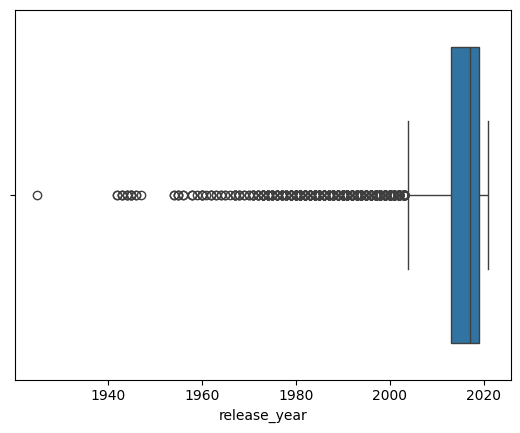

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x=df["release_year"]
)

plt.show()

**Normalization**

In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["release_year_normalized"] = scaler.fit_transform(
    df[["release_year"]]
)

**Save Clean Dataset**

In [31]:
df.to_csv(
    "data/cleaned_dataset.csv",
    index=False
)

**SQLite Integration**

In [32]:
import sqlite3

conn = sqlite3.connect(
    "data/analytics.db"
)

In [33]:
df.to_sql(
    "Netflix",
    conn,
    if_exists="replace",
    index=False
)

8807

In [34]:
pd.read_sql(
    "SELECT * FROM Netflix LIMIT 5",
    conn
)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,release_year_normalized
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",0.989583
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",1.000000
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.000000
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.000000
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,1.000000


**SQL Analytics**

In [36]:
query = """
SELECT type,
       COUNT(*) AS total
FROM Netflix
GROUP BY type
"""

pd.read_sql(query, conn)

,type,total
0,Movie,6131
1,TV Show,2676


In [37]:
query = """
SELECT country,
       COUNT(*) AS total
FROM Netflix
GROUP BY country
ORDER BY total DESC
LIMIT 10
"""

countries = pd.read_sql(
    query,
    conn
)

countries

,country,total
0,United States,2818
1,India,972
2,Unknown,831
3,United Kingdom,419
4,Japan,245
5,South Korea,199
6,Canada,181
7,Spain,145
8,France,124
9,Mexico,110


In [38]:
query = """
SELECT rating,
       COUNT(*) AS total
FROM Netflix
GROUP BY rating
ORDER BY total DESC
"""

ratings = pd.read_sql(
    query,
    conn
)

**Visualizations**

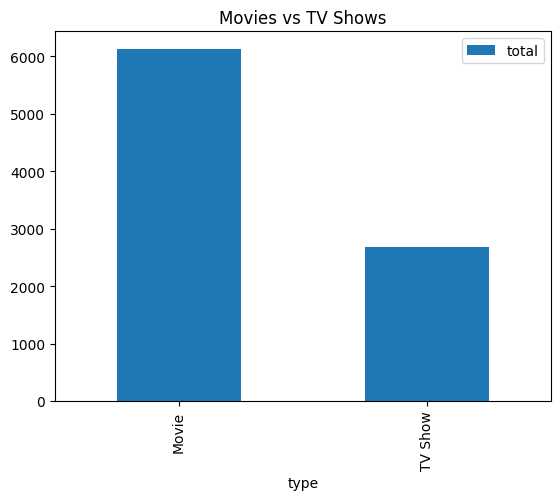

In [39]:
import matplotlib.pyplot as plt

content = pd.read_sql("""
SELECT type,
       COUNT(*) AS total
FROM Netflix
GROUP BY type
""", conn)

content.plot(
    kind="bar",
    x="type",
    y="total"
)

plt.title(
    "Movies vs TV Shows"
)

plt.show()

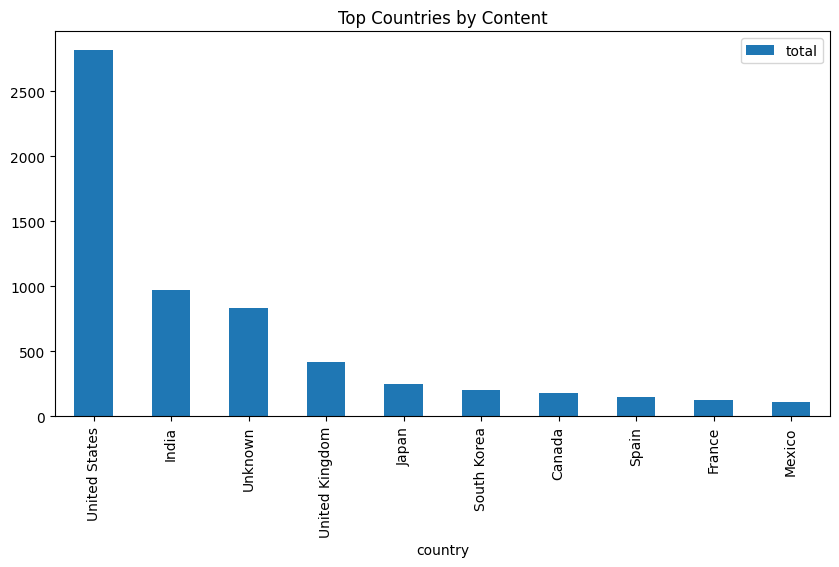

In [40]:
countries.plot(
    kind="bar",
    x="country",
    y="total",
    figsize=(10,5)
)

plt.title(
    "Top Countries by Content"
)

plt.show()

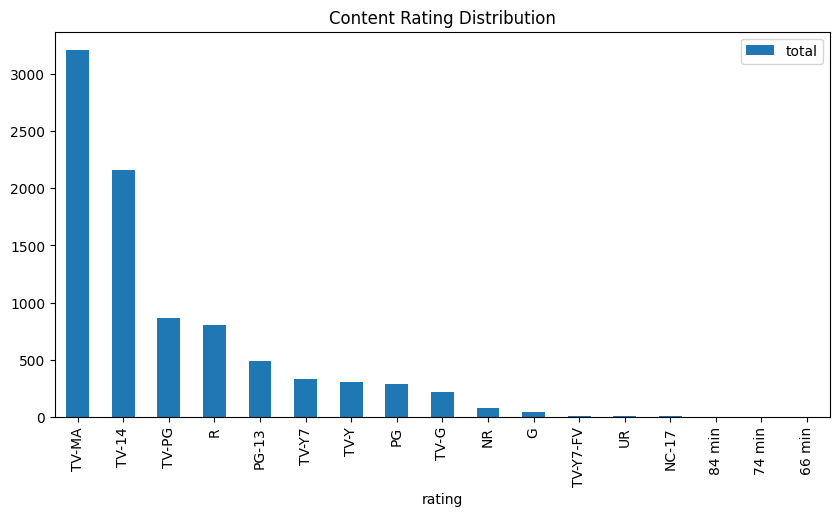

In [41]:
ratings.plot(
    kind="bar",
    x="rating",
    y="total",
    figsize=(10,5)
)

plt.title(
    "Content Rating Distribution"
)

plt.show()